# Семинар 10

# Метод Ньютона. Квази-Ньютоновские методы

## 1. Метод Ньютона

### 1.1. Идея метода Ньютона. Метод Ньютона
Рассмотрим задачу

$$
\min\limits_{x\ \in \mathbb{R}^n} f(x).
$$

- Градиентный спуск $\equiv$ **линейная** аппроксимация $f$
- Метод Ньютона $\equiv$ **квадратичная** аппроксимация $f$:

$$
f(x + h) \approx f(x) + \langle f'(x), h \rangle + \frac{1}{2}h^{\top}f''(x)h \to \min_{h}
$$

Из необходимого условия минимума:

$$
f'(x) + f''(x) h = 0, \qquad h^* = -(f''(x))^{-1} f'(x)
$$


- **Классический метод Ньютона**: $\alpha_k \equiv 1$



$$x_{k+1} = x_k - H(x_k)^{-1} \nabla f(x_k)$$
- **Демпфированный метод Ньютона**: $\alpha_k$ выбирается на каждой итерации по заданному правилу
$$x_{k+1} = x_k - \alpha_k H(x_k)^{-1} \nabla f(x_k)$$

$\langle \nabla f, h \rangle \leq 0$

$\langle \nabla f, h \rangle = -\langle \nabla f, H^{-1} \nabla f \rangle = -(\nabla f(x))^\top  (H(x))^{-1} \nabla f(x) \leq 0$ для $x$, что $H(x)\succeq l I$.

### 1.2. Теорема сходимости (Ю. Е. Нестеров Введение в выпуклую оптимизацию, $\S$ 1.2)

**Теорема.** Пусть функция $f(x)$
- дважды дифференцируема и её гессиан удовлетворяет условию Липшица с константой $M$
- существует точка локального минимума с положительно определённым гессианом

$$
f''(x^*) \succeq l\mathbf{I}, \; l > 0
$$

- начальная точка $x_0$ достаточно близка к точке минимума, в частности

$$
\|x_0 - x^*\|_2 \leq \frac{2l}{3M}
$$

Тогда метод Ньютона сходится **квадратично**:

$$
\|x_{k+1} - x^* \|_2 \leq \dfrac{M\|x_k - x^*\|^2_2}{2 (l - M\|x_k - x^*\|_2)} \leq q^{k^2}\|x_0 - x^*\|_2.
$$

### 1.3. Вычислительная сложность и реализация

Узкие места метода Ньютона:

- формирование и хранение гессиана
- решение систем линейных уравнений

$$
f''(x_k)h = -f'(x_k)
$$

In [1]:
import time

import numpy as np
import scipy
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib

import jax
import jax.numpy as jnp
# from jax.config import config


from methods import GradientDescent, parse_logs, CG_PR, CG_FR
from step_size import ConstantStepSize, Armijo, Wolfe

In [2]:
# config.update("jax_enable_x64", True)

In [3]:
matplotlib.use("Agg")
params = {
    "legend.fontsize": 20,
    "legend.handlelength": 4,
    "axes.labelsize": 45,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "lines.linewidth": 4,
    "axes.titlesize": 30,
}
matplotlib.rcParams.update(params)

In [4]:
class Newton:
    def __init__(self, StepSizeChoice, return_history=True, name=None):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history

        self.c = None
        self.lower = None

        self.history = []

    def solve_newton(self, H, g):
        h = np.linalg.solve(H, g)
        return h

    def solve(self, x0, f, gradf, hessf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        x_prev = None
        while x_prev is None or np.linalg.norm(gradf(x)) > tol:
            H = hessf(x)
            g = gradf(x)
            h = self.solve_newton(H, -g)
            alpha = self.StepSizeChoice(x, h, k, gradf, f)
            x_prev, x = x, x + alpha * h
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

### 1.4. Эксперименты: cравнение метода Ньютона с градиентным спуском

Задача нахождения аналитического центра системы неравенств $Ax \leq 1$ при условии $|x_i| \leq 1$

$$
f(x) = - \sum_{i=1}^m \log(1 - a_i^{\top}x) - \sum\limits_{i = 1}^n \log (1 - x^2_i) \to \min_x
$$

$$
f'(x) - ? \quad f''(x) - ?
$$ 

$f(x_{k+1}) \leq f(x_k) +\alpha_k \beta \langle f'_k, h_k\rangle$

#### Вспомогательные функции

In [5]:
def log(x):
    logx = np.log(x)
    return np.nan_to_num(logx, nan=-np.inf)

In [6]:
def return_center_problem(A):
    def f(x):
        return -np.sum(log(1 - A.T.dot(x))) - np.sum(log(1 - x * x))

    def gradf(x):
        return np.sum(A.dot(np.diagflat(1 / (1 - A.T.dot(x)))), axis=1) + 2 * x / (
            1 - np.power(x, 2)
        )

    def hessf(x):
        return A.dot(np.diagflat(1 / (1 - A.T.dot(x)) ** 2)).dot(A.T) + np.diagflat(
            2 * (1 + x**2) / (1 - x**2) ** 2
        )

    return f, gradf, hessf

#### Сравнение с градиентным спуском в размерности n=2000

In [7]:
np.random.seed(1)
n = 2000
m = 200
x0 = np.zeros((n,))
A = np.random.rand(n, m) * 10
f, gradf, hessf = return_center_problem(A)

In [8]:
newton = Newton(Armijo(rho=0.9, beta=0.1, alpha0=1.0))
x_newton = newton.solve(x0, f, gradf, hessf, tol=1e-6, max_iter=100)

gd = GradientDescent(Armijo(rho=0.9, beta=0.1, alpha0=1))
x_gd = gd.solve(x0, f, gradf, tol=1e-6, max_iter=100)

/tmp/ipykernel_940727/1209577179.py:2: RuntimeWarning: invalid value encountered in log
  logx = np.log(x)


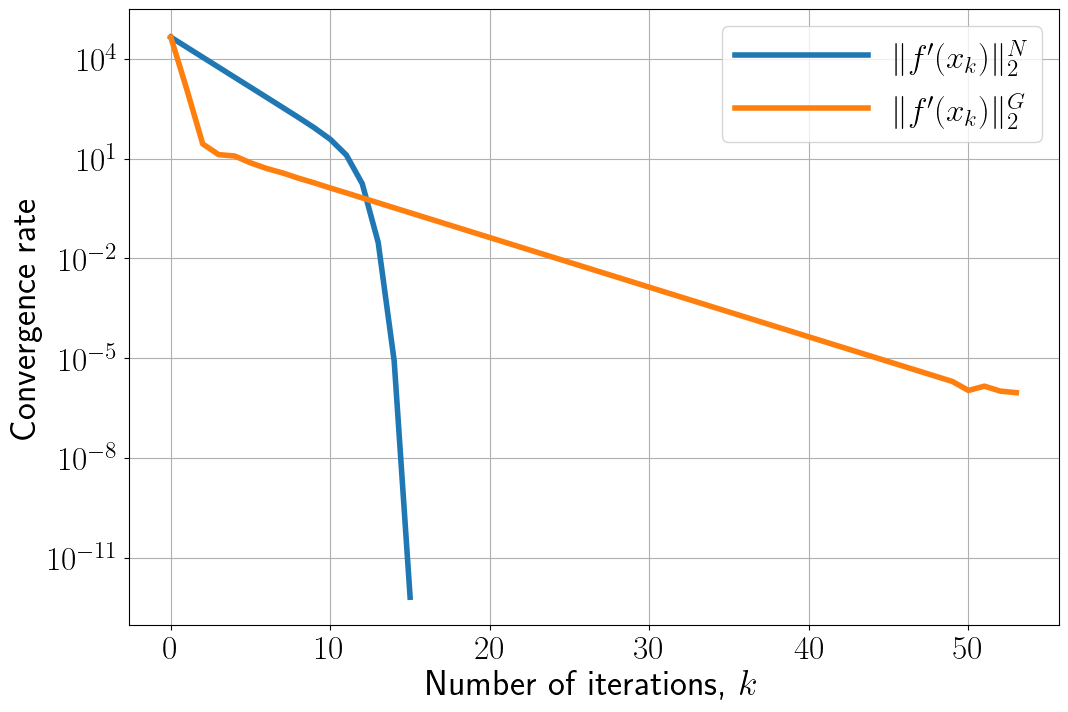

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rc("text", usetex=True)
plt.figure(figsize=(12, 8))

plt.semilogy(
    [np.linalg.norm(gradf(x)) for x, _ in newton.history], label="$\| f'(x_k) \|^{N}_2$"
)
plt.semilogy(
    [np.linalg.norm(gradf(x)) for x, _ in gd.history], label="$\| f'(x_k) \|^{G}_2$"
)

plt.grid()
plt.xlabel(r"Number of iterations, $k$", fontsize=26)
plt.ylabel(r"Convergence rate", fontsize=26)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(loc="best", fontsize=24)

In [10]:
%timeit newton.solve(x0, f, gradf, hessf, tol=1e-6, max_iter=100)
%timeit gd.solve(x0, f, gradf, tol=1e-6, max_iter=100)

1.32 s ± 105 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


/tmp/ipykernel_940727/1209577179.py:2: RuntimeWarning: invalid value encountered in log
  logx = np.log(x)


455 ms ± 138 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### Сравнение с градиентным спуском в размерности n=200 при m=200

In [11]:
np.random.seed(1)
n = 200
m = 200
x0 = np.zeros((n,))
A = np.random.rand(n, m) * 10
f, gradf, hessf = return_center_problem(A)

In [12]:
%timeit newton.solve(x0, f, gradf, hessf, tol=1e-6, max_iter=100)
%timeit gd.solve(x0, f, gradf, tol=1e-6, max_iter=100)

22.3 ms ± 4.93 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


/tmp/ipykernel_940727/1209577179.py:2: RuntimeWarning: invalid value encountered in log
  logx = np.log(x)


98.1 ms ± 4.84 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 1.5. Модификации метода Ньютона Метод Ньютона с модификацией гессиана

- На каждой итерации можно решать СЛАУ неточно при помощи CG

- Можно обновлять гессиан с некоторой периодичностью

- Проблемы с неположительной определенностью
    - Если $f''(x)$ неположительно определён, использовать положительно определённую матрицу $f''(x) + \Delta E$
    - Матрицу $\Delta E$ можно выбирать различными способами исходя из следующей задачи
    $$
    \Delta E = \arg\min \|\Delta E\|, \quad \text{s.t. } f''(x) + \Delta E \succ \delta I
    $$
        - $\|\cdot\|_2$: $\Delta E = \tau I$, где $\tau = \max(0, \delta - \lambda_{\min}(f''(x)))$, где $\delta > 0$ - заданная оценка снизу минимального собственного значения матрицы $f''(x) + \Delta E$

### Pro & Contra

Pro

- квадратичная сходимость вблизи решения
- высокая точность полученного решения
- параметры слабо влияют на скорость сходимости

Contra

- необходимо хранить гессиан на каждой итерации: $O(n^2)$ памяти
- необходимо решать линейные системы: $O(n^3)$ операций
- гессиан может оказаться вырожден
- гессиан может не быть положительно определён $\to$ направление $-(f''(x))^{-1}f'(x)$ может не быть направлением убывания

## 2. Квазиньютоновские методы: между двух огней

### 2.1. Общая идея

#### Сравнительный анализ метода Ньютона и градиентного спуска

Метод | Скорость сходимости | Сложность итерациии| Требования к $f(x)$
:---: | :---: | :---: | :---:
Градиентный спуск | Глобально линейная | $O(n) + $ определение шага | Дифференцируема; градиент липшицев
Метод Ньютона | Локально квадратичная | $O(n^3) + $ определение шага | Дважды диференцируема; гессиан липшицев, положительно определён

#### Единообразный способ получения метода Ньютона и градиентного спуска 

- градиентный метод получен из аппроксимации первого порядка:

$$
f_G(x) \approx f(y) + \langle f'(y), x - y \rangle + \frac{1}{2}(x-y)^{\top} \frac{1}{\alpha}I(x - y)
$$

причём при $\alpha \in (0, 1/L], f(x) \leq f_G(x)$, то есть $f_G$ - глобальная оценка $f(x)$
- метод Ньютона получен из аппроксимации второго порядка

$$
f_N(x) \approx f(y) + \langle f'(y), x - y \rangle + \frac{1}{2} (x-y)^{\top}f''(y)(x-y)
$$

**Идея:** использовать промежуточную аппроксимацию вида

$$
f_q(x) \approx f(y) + \langle f'(y), x - y \rangle + \frac{1}{2} (x-y)^{\top}{\color{red}{B(y)}}(x-y),
$$

которая даёт переход к следующей точке:

$$
x_{k+1} = x_k - \alpha_k B^{-1}_k f'(x_k) = x_k - \alpha_k H_k f'(x_k)
$$

### 2.2. Квазиньютоновское уравнение (Secant equation)

1. Матрица $B_{k+1} \in \mathbb{S}^n_{++}$ должна быть положительно определена.

2. Новая матрица $B_k$ должна удовлетворять **квазиньютоновскому уравнению**

$$
B_{k+1}s_k = y_k,
$$

где $s_k = x_{k+1} - x_k$ и $y_k = f'(x_{k+1}) - f'(x_k)$. Это уравнение будет иметь решение только при $s^{\top}_k y_k > 0$. *Почему?*

$\langle f'(x_{k+1}), h_k \rangle \geq \beta_2 \langle f'(x_k), h_k \rangle$

$\langle f'(x_{k+1})-f'(x_k), h_k \rangle \geq (1-\beta_2) \langle -f'(x_k), h_k \rangle$


$\frac{1}{\alpha_k} \langle y_k, s_k \rangle \geq (1-\beta_2) \langle -f'(x_k), h_k \rangle$

Если $h_k$ - направление убывания, то 
$\frac{1}{\alpha_k} \langle y_k, s_k \rangle \geq (1-\beta_2) \langle -f'(x_k), h_k \rangle >0$


Правило Вольфа (условие кривизны) гарантирует условие выше.

### 2.3. DFP (Davidon-Fletcher-Powell)

\begin{align*}
& \min_B \| B_k - B \| \\
\text{s.t. } & B = B^{\top}\\
& Bs_k = y_k
\end{align*}

Решение:

$$
B_{k+1} = (I - \rho_k y_k s^{\top}_k)B_k(I - \rho_k s_ky^{\top}_k) + \rho_k y_k y^{\top}_k,
$$

где $\rho_k = \dfrac{1}{y^{\top}_k s_k}$,

или с помощью формулы Шермана-Морисона-Вудбери

$$
H_{k+1} = B^{-1}_{k+1} = H_k - \dfrac{(H_ky_k)(H_ky_k)^\top}{y^{\top}_kH_ky_k} + \dfrac{s_ks^{\top}_k}{y^{\top}_ks_k}
$$

In [13]:
class DFP:
    def __init__(self, StepSizeChoice, return_history=True, name=None):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history
        self.history = []

    @staticmethod
    def update_H(H, s, y):
        Hy = H @ y
        H1 = np.outer(Hy, Hy) / (np.dot(y, Hy) + 1e-12)
        H2 = np.outer(s, s) / (y.T @ s + 1e-12)
        H_next = H - H1 + H2
        return H_next

    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        x_prev = None
        g_next = gradf(x)
        H = np.identity(x.shape[0])
        while x_prev is None or np.linalg.norm(gradf(x)) > tol:
            g = g_next
            h = -H @ g
            alpha = self.StepSizeChoice(x, h, k, gradf, f)
            x_prev, x = x, x + alpha * h
            g_next = gradf(x)
            s = x - x_prev
            y = g_next - g
            # if k == 0:
            #    H = np.identity(x.shape[0]) * (y.T @ s) / (y.T @ y)
            H = DFP.update_H(H, s, y)
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

### 2.4. BFGS


\begin{align*}
&𝐻_{k+1} =\arg \min_{H_{k+1}} \| H_k - H_{k+1} \| \\
\text{s.t. } & H_{k+1} = H_{k+1}^{\top}\\
& H_{k+1}y_k = s_k
\end{align*}

Формула пересчёта для метода BFGS:

$$
H_{k+1} = (I - \rho_k s_ky^{\top}_k)H_k(I - \rho_k y_k s^{\top}_k) + \rho_k s_k s^{\top}_k,
$$

где $\rho_k = \dfrac{1}{y^{\top}_k s_k}$

In [14]:
class BFGS:
    def __init__(self, StepSizeChoice, return_history=True, name=None):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history
        self.history = []

    @staticmethod
    def update_H(H, s, y):
        rho = 1 / (y.T @ s)
        ssT = np.outer(s, s)
        H1 = (rho**2) * np.dot(y, H @ y) * ssT
        H2 = rho * np.outer(s, H @ y)
        H3 = H2.T
        H = H + H1 - H2 - H3 + rho * ssT
        return H

    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        x_prev = None
        g_next = gradf(x)
        H = np.identity(x.shape[0])
        while x_prev is None or np.linalg.norm(gradf(x)) > tol:
            g = g_next
            h = -H @ g
            alpha = self.StepSizeChoice(x, h, k, gradf, f)
            x_prev, x = x, x + alpha * h
            g_next = gradf(x)
            s = x - x_prev
            y = g_next - g
            if k == 0:
                H = np.identity(x.shape[0]) * (y.T @ s) / (y.T @ y)
            H = BFGS.update_H(H, s, y)
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

### Детали реализации

- Не должно быть операций сложностью $O(n^3)$, то есть никаких матричных умножений и решений линейных систем (cf. [реализацию в SciPy](https://github.com/scipy/scipy/blob/v0.18.1/scipy/optimize/optimize.py#L874-L976))
- Правило Вольфа гарантирует соблюдения условия кривизны $y_k^{\top}s_k > 0$
- Параметры в правиле Вольфа обычно следующие
    - $\alpha_0 = 1$ необходим для сверхлинейной скорости
    - $\beta_1 = 10^{-4}$, $\beta_2 = 0.9$
- Способы инициализации $H_0$
    - единичная матрица
    - $H_0 = \frac{y_0^{\top}s_0}{y_0^{\top}y_0}I$ **после** первого шага, но до вычисления $H_1$.При вычислении $x_1$  используется $H_0 = I$
    - $H_0 = \delta \|g_0\|^{-1}_2 I$, параметр $\delta$ необходимо заранее задать
- При использовании $B$ вместо $H$ нужно хранить $B$ в виде $LDL^{\top}$ разложения и обновлять не саму матрицу $B$, а её разложение. Это явно делается за $O(n^2)$. Вычисление $h_k$ - это решение линейной системы с предвычисленным раздложением матрицы, следовательно сложность также $O(n^2)$. Этот подход позволяет контролировать устройчивость в диагонали матрицы $D$. На практике предпочтительнее работать с матрицей $H$


### 2.5. Barzilai-Borwein method

- Первая [статья](http://pages.cs.wisc.edu/~swright/726/handouts/barzilai-borwein.pdf) об этом методе опубликована в 1988, в журнале IMA Journal of Numerical Analysis
- [Статья](http://papers.nips.cc/paper/6286-barzilai-borwein-step-size-for-stochastic-gradient-descent.pdf) на NIPS 2016 о модификации этого метода в случае использования стохастической оценки градиента
- Идея: комбинация идеи наискорейшего спуска и квазиньютоновского метода

#### Идея метода

- Наискорейший спуск: $x_{k+1} = x_k - \alpha_k f'(x_k)$, $\alpha_k = \arg \min\limits_{\alpha > 0} f(x_{k+1})$
- Метод Ньютона: $x_{k+1} = x_k - (f''(x_k))^{-1} f'(x_k)$
- Аппроксимация гессиана диагональной матрицей:

$$
\alpha_k f'(x_k) = \alpha_k I f'(x_k) = \left( \frac{1}{\alpha_k} I \right)^{-1} f'(x_k) \approx \left( f''(x_k)\right)^{-1} f'(x_k)
$$

- Как найти $\alpha_k$?

#### Два способа найти $\alpha_k$

- Первый способ
    - Задача
    
    $$
    \min_{\beta} \|\beta s_{k-1} - y_{k-1} \|^2_2
    $$
    
    - Решение
    
    $$
    \alpha = \frac{1}{\beta} = \frac{s^{\top}_{k-1} s_{k-1}}{s^{\top}_{k-1} y_{k-1}}
    $$
    
- Второй способ
    - Задача
    
    $$
    \min_{\alpha} \| s_{k-1} - \alpha y_{k-1} \|^2_2
    $$
    
    - Решение
    
    $$
    \alpha = \frac{s^{\top}_{k-1} y_{k-1}}{y^{\top}_{k-1} y_{k-1}}
    $$

In [15]:
class BB_method:
    def __init__(self, StepSizeChoice, return_history=True, name=None, type_method="I"):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history
        self.history = []
        self.type_method = type_method

    @staticmethod
    def alpha_calc(s, y, type_method):
        if type_method == "I":
            alpha = (s.T @ s) / (s.T @ y + 1e-12)
        elif type_method == "II":
            alpha = (s.T @ y) / (y.T @ y + 1e-12)
        else:
            raise Exception("Unrecognized type of method")

        return alpha

    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        x_prev = None
        g_next = gradf(x)
        alpha = None
        while x_prev is None or np.linalg.norm(gradf(x)) > tol:
            g = g_next
            if alpha is None:
                alpha = self.StepSizeChoice(x, -g, k, gradf, f)
            x_new = x - alpha * g
            fnew = f(x_new)
            if np.isnan(fnew) or fnew >= 1e10:
                alpha = self.StepSizeChoice(x, -g, k, gradf, f)
                x_new = x - alpha * g
            x_prev, x = x, x_new
            g_next = gradf(x)
            s = x - x_prev
            y = g_next - g
            alpha = BB_method.alpha_calc(s, y, type_method=self.type_method)
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

### 2.6. Limited Memory BFGS (L-BFGS)

- В методе BFGS нужна не сама матрица $H$, а только функция умножения её на вектор 
- Поскольку требуется локальная оценка гессиана, старые значения векторов $s$ и $y$ могут портить текущую оценку

**Идея**

- Хранить $m\ll n$ последних векторов $s$ и $y$ - снижение требуемой памяти с $n^2$ до $mn$
- Выполнение умножения на вектор рекурсивно, без явного формирования матрицы $H$

Формула пересчёта для метода BFGS:

$$
H_{k+1} = (I - \rho_k s_ky^{\top}_k)H_k(I - \rho_k y_k s^{\top}_k) + \rho_k s_k s^{\top}_k,
$$

где $s_k = x_{k+1} - x_k; y_k = f'(x_{k+1}) - f'(x_k)$ и $\rho_k = \dfrac{1}{y^{\top}_k s_k}$.

Переобозначим: $V_k=I - \rho_k y_ks^{\top}_k$:

$$
H_{k} = V_{k-1}^\top H_{k-1} V_{k-1} + \rho_{k-1} s_{k-1} s^{\top}_{k-1},
$$

Раскроем предыдущие $m$ итераций

<img src="pics/LBFGS_formula.png" width=500>

$s_{k-m+d}^\top (V_{k-m+d} \dots V_{k-1} \nabla f(x_k))$ - $O(dn)$ + O(n)

$h_k = H_k\nabla f(x_k)$

Получим эффективный алгоритм умножения:

<img src="pics/LBFGS_two_loop.png" width=350>

*Скриншоты из книги **J. Nocedel, S.J. Wright "Numerical Optimization"** )*

In [16]:
class LBFGS:
    def __init__(self, StepSizeChoice, m=10, return_history=True, name=None):
        self.name = name
        self.StepSizeChoice = StepSizeChoice
        self.return_history = return_history
        self.history = []
        self.m = m
        self.s_hist = []
        self.y_hist = []

    def update_lists(self, s, y):
        self.s_hist.append(s)
        self.s_hist = self.s_hist[-self.m :]
        self.y_hist.append(y)
        self.y_hist = self.y_hist[-self.m :]

    def get_h(self, current_grad):
        m = len(self.s_hist)
        if m == 0:
            return -current_grad

        q = current_grad
        alpha = np.zeros(len(self.s_hist))
        rho = np.zeros(len(self.s_hist))
        for i in range(m - 1, -1, -1):
            rho[i] = 1.0 / self.s_hist[i].dot(self.y_hist[i])
            alpha[i] = self.s_hist[i].dot(q) * rho[i]
            q = q - alpha[i] * self.y_hist[i]

        s, y = self.s_hist[-1], self.y_hist[-1]
        r = q * y.dot(s) / y.dot(y)

        for i in range(m):
            beta = rho[i] * self.y_hist[i].dot(r)
            r = r + self.s_hist[i] * (alpha[i] - beta)
        return -r

    def solve(self, x0, f, gradf, tol=1e-3, max_iter=10000):
        self.history = [(x0, time.time())]
        x = x0.copy()
        k = 0
        x_prev = None
        while x_prev is None or np.linalg.norm(gradf(x)) > tol:
            g = gradf(x)
            h = self.get_h(g)
            alpha = self.StepSizeChoice(x, h, k, gradf, f)
            x_prev, x = x, x + alpha * h
            g_next = gradf(x)
            s = x - x_prev
            y = g_next - g
            self.update_lists(s, y)
            if self.return_history:
                self.history.append((x, time.time()))
            if k >= max_iter:
                break
            k += 1
        return x

## 3. Эксперименты

### 3.1. Плохо обусловленная задача 

In [17]:
n = 100
D = np.arange(1, n + 1)
U = np.random.randn(n, n)
U, _ = np.linalg.qr(U)
A = U.dot(np.diag(D)).dot(U.T)
b = np.random.randn(n)
eig_vals = np.linalg.eigvals(A)
print("Condition number = {}".format(np.max(eig_vals) / np.min(eig_vals)))

Condition number = 99.99999999999987


In [18]:
def f(x):
    return 0.5 * x.T.dot(A.dot(x)) - b.dot(x)
def gradf(x):
    return A.dot(x) - b
x0 = np.random.randn(n)

In [19]:
wolfe_step_size = Wolfe(alpha0=1, beta1=1e-4, beta2=0.3)
methods = [
    DFP(wolfe_step_size, name="DFP"),
    BFGS(wolfe_step_size, name="BFGS"),
    LBFGS(wolfe_step_size, m=10, name="L-BFGS"),
    BB_method(wolfe_step_size, type_method="I", name="BB I"),
    BB_method(wolfe_step_size, type_method="II", name="BB II"),
    GradientDescent(wolfe_step_size, name="GD"),
]

In [20]:
N = 2000
tol = 1e-4
for method in methods:
    print(method.name)
    x = method.solve(x0, f, gradf, tol=1e-4, max_iter=N)
    t = method.history[-1][1] - method.history[0][1]
    print("\t Tolerance achived ", np.linalg.norm(gradf(x)) <= tol)

DFP
	 Tolerance achived  True
BFGS
	 Tolerance achived  True
L-BFGS
	 Tolerance achived  True
BB I
	 Tolerance achived  True
BB II
	 Tolerance achived  True
GD
	 Tolerance achived  True


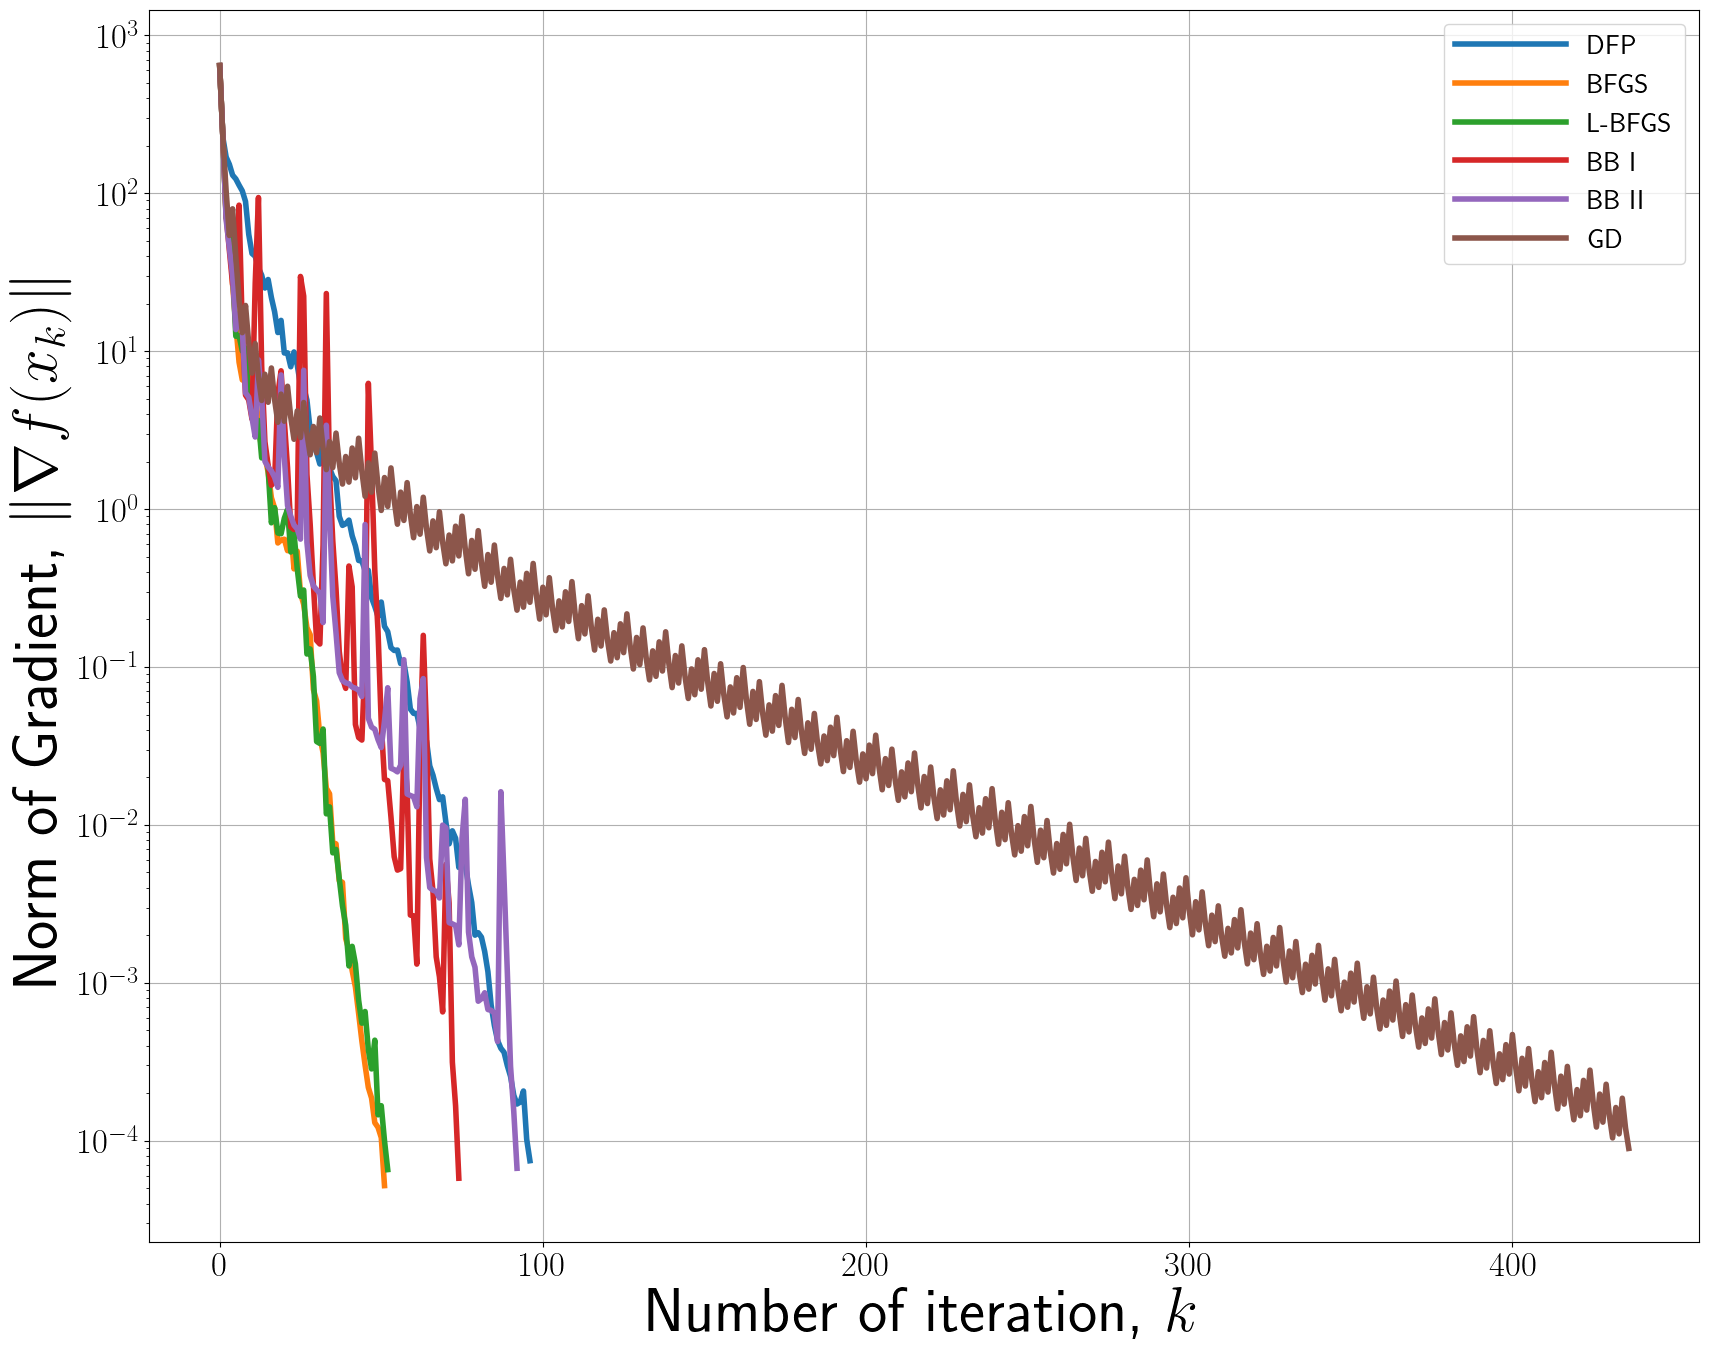

In [21]:
%matplotlib inline
plt.figure(figsize=(20, 16))


def funcx(x):
    return np.linalg.norm(gradf(x))


for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

In [ ]:
from scipy.optimize import fmin_l_bfgs_b

%timeit fmin_l_bfgs_b(f, x0=x0, m=10, fprime=gradf, pgtol=1e-4)
%timeit LBFGS(wolfe_step_size, m=10, name="L-BFGS").solve(x0, f, gradf, tol=1e-4, max_iter=N)

8.85 ms ± 2.19 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
49.1 ms ± 9.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
from scipy.optimize import fmin_bfgs

%timeit fmin_bfgs(f, x0=x0, fprime=gradf, gtol=1e-4, disp=False)
%timeit BFGS(wolfe_step_size, name="BFGS").solve(x0, f, gradf, tol=1e-4, max_iter=N)

115 ms ± 16.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
67.1 ms ± 18.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
import timeit

t_diff = []
t_scipy = []
t_bfgs = []
n_list = [100, 1000, 3000, 4000, 5000]
for n in n_list:
    D = np.linspace(1, 10, n)
    U = np.random.randn(n, n)
    U, _ = np.linalg.qr(U)
    A = U.dot(np.diag(D)).dot(U.T)
    b = np.random.randn(n)
    eig_vals = np.linalg.eigvals(A)
    f = lambda x: 0.5 * x.T.dot(A.dot(x)) - b.dot(x)
    gradf = lambda x: A.dot(x) - b
    x0 = np.random.randn(n)
    t1 = timeit.timeit(
        lambda: fmin_bfgs(f, x0=x0, fprime=gradf, gtol=1e-4, disp=False, maxiter=1),
        number=30,
    )
    t2 = timeit.timeit(
        lambda: BFGS(wolfe_step_size).solve(x0, f, gradf, tol=1e-4, max_iter=1),
        number=30,
    )
    t_diff.append(t1 / t2)
    t_scipy.append(t1)
    t_bfgs.append(t2)
    print("n = ", n, t_diff[-1])

n =  100 0.44395513343126863
n =  1000 1.8839085530755928
n =  3000 2.8025059643979806
n =  4000 3.201442973249507
n =  5000 3.684505971049624


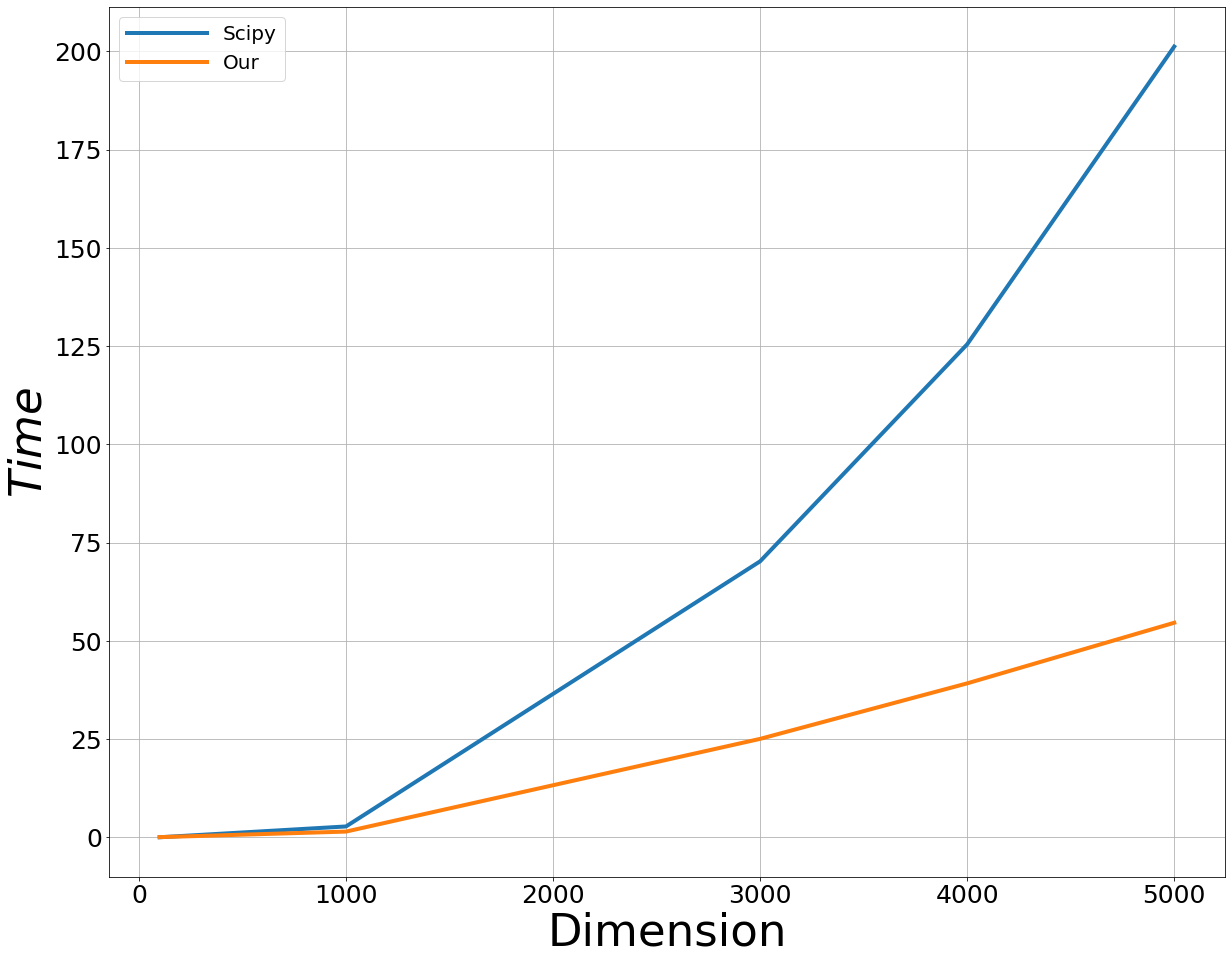

In [76]:
plt.figure(figsize=(20, 16))
plt.plot(n_list, t_scipy, label="Scipy")
plt.plot(n_list, t_bfgs, label="Our")
plt.grid()
plt.ylabel(r"$Time$")
plt.xlabel(r"Dimension")
plt.legend()

Text(0.5, 0, 'Dimension')

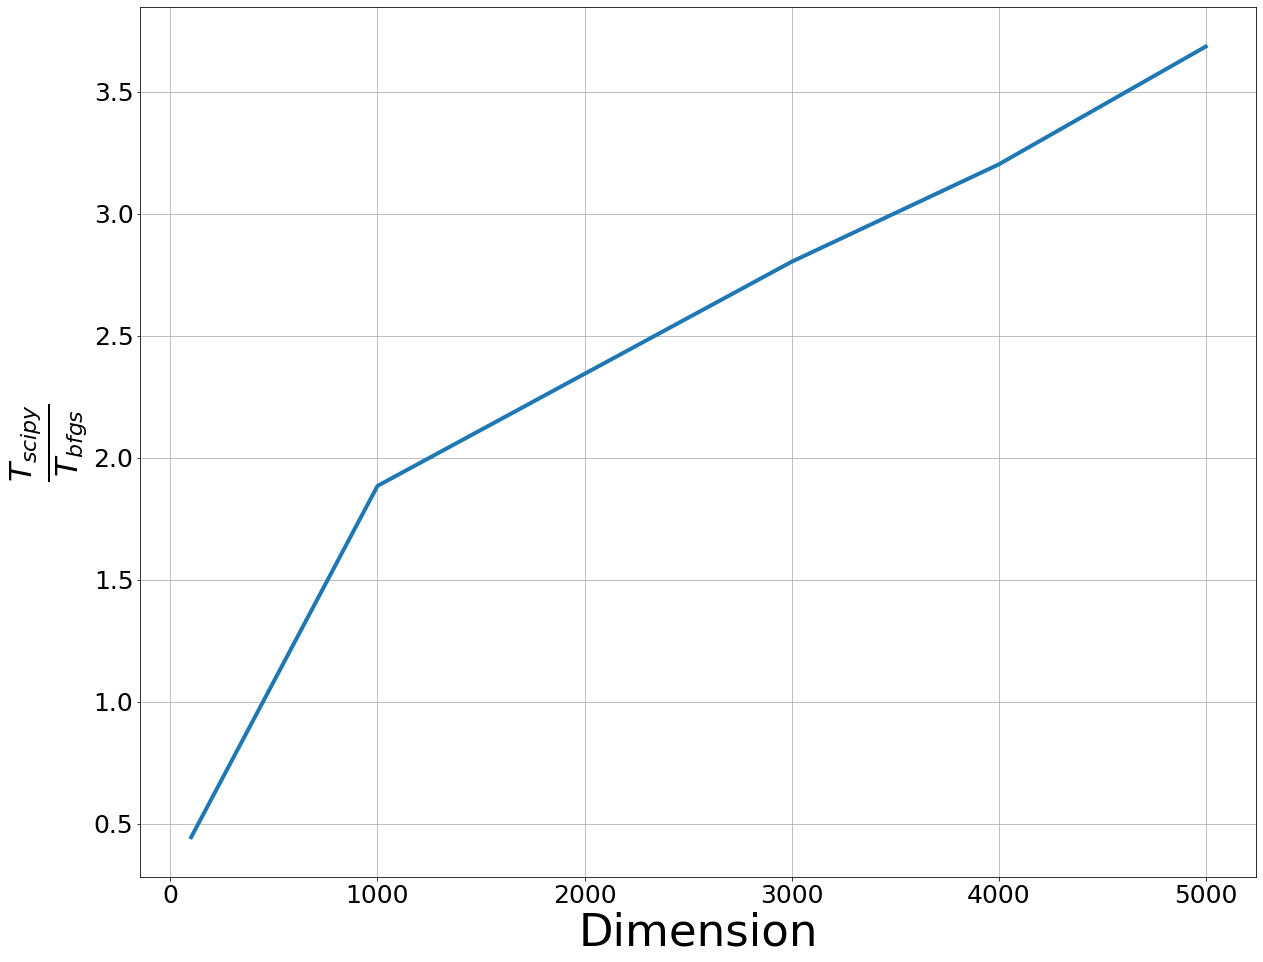

In [77]:
plt.figure(figsize=(20, 16))
plt.plot(n_list, t_diff)
plt.grid()
plt.ylabel(r"$\frac{T_{scipy}}{T_{bfgs}}$")
plt.xlabel(r"Dimension")


### 3.2. Поиск аналитического центра системы неравенств

$$
f(x) = - \sum_{i=1}^m \log(1 - a_i^{\top}x) - \sum\limits_{i = 1}^n \log (1 - x^2_i) \to \min_x
$$

In [80]:
np.random.seed(1)
n = 100
m = 200
x0 = np.zeros(n)
max_iter = 100
A = np.random.randn(n, m) * 10

In [ ]:
def jnplog(x):
    x = 1 / 2 * (x + jnp.abs(x))
    logx = jnp.log(x)
    return logx

In [ ]:
# f_, gradf_, _ = return_center_problem(A)
# %timeit gradf_(x0)

f1 = lambda x, A: -jnp.sum(jnplog(1 - A.T.dot(x))) - jnp.sum(jnplog(1 - x * x))
f = lambda x: f1(x, A)
gradf = jax.grad(f1, argnums=0, has_aux=False)
jit_gradf = jax.jit(gradf)
gradf = lambda x: np.array(jit_gradf(x, A).block_until_ready())
# %timeit gradf(x0)

In [ ]:
wolfe_step_size = Wolfe(alpha0=1, beta1=1e-4, beta2=0.3)
methods = [
    DFP(wolfe_step_size, name="DFP"),
    BFGS(wolfe_step_size, name="BFGS"),
    BB_method(wolfe_step_size, type_method="I", name="BB I"),
    BB_method(wolfe_step_size, type_method="II", name="BB II"),
    LBFGS(wolfe_step_size, m=3, name="L-BFGS, m=3"),
    LBFGS(wolfe_step_size, m=10, name="L-BFGS, m=10"),
    LBFGS(wolfe_step_size, m=50, name="L-BFGS, m=50"),
    CG_PR(Wolfe(alpha0=1), name="CG PR"),
    GradientDescent(wolfe_step_size, name="GD"),
]

In [ ]:
N = 2000
tol = 1e-4
for method in methods:
    print(method.name)
    x = method.solve(x0, f, gradf, tol=1e-4, max_iter=N)
    t = method.history[-1][1] - method.history[0][1]
    print("\t Tolerance achived ", np.linalg.norm(gradf(x)) <= tol)

DFP
	 Tolerance achived  True
BFGS
	 Tolerance achived  True
BB I
	 Tolerance achived  True
BB II
	 Tolerance achived  True
L-BFGS, m=3
	 Tolerance achived  True
L-BFGS, m=10
	 Tolerance achived  True
L-BFGS, m=50
	 Tolerance achived  True
CG PR
	 Tolerance achived  True
GD
	 Tolerance achived  False


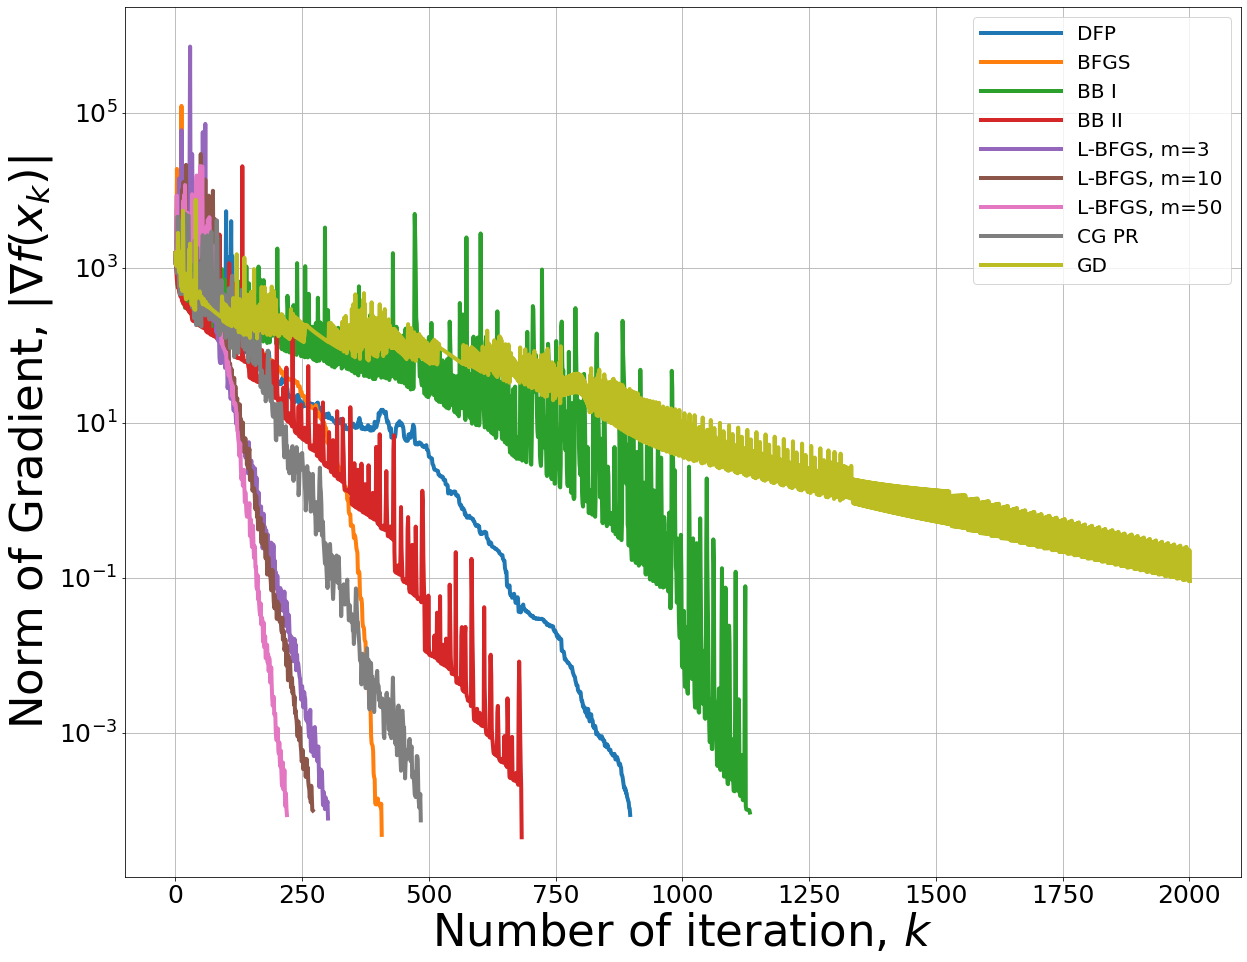

In [85]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: np.linalg.norm(gradf(x))
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Norm of Gradient, $\|\nabla f(x_k)\|$")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

In [ ]:
N = 2000
tol = 1e-4
for method in methods:
    print(method.name)
    t = method.history[-1][1] - method.history[0][1]
    print("\t Time {:.2f} s".format(t))
    print("\t Tolerance achived ", np.linalg.norm(gradf(x)) <= tol)

DFP
	 Time 9.34 s
	 Tolerance achived  False
BFGS
	 Time 1.96 s
	 Tolerance achived  False
BB I
	 Time 3.08 s
	 Tolerance achived  False
BB II
	 Time 0.99 s
	 Tolerance achived  False
L-BFGS, m=3
	 Time 0.71 s
	 Tolerance achived  False
L-BFGS, m=10
	 Time 0.95 s
	 Tolerance achived  False
L-BFGS, m=50
	 Time 0.90 s
	 Tolerance achived  False
CG PR
	 Time 7.58 s
	 Tolerance achived  False
GD
	 Time 30.93 s
	 Tolerance achived  False


In [ ]:
N = 2000
tol = 1e-4
for method in methods[:-1]:
    print(method.name)
    %timeit x=method.solve(x0, f, gradf, tol=1e-4, max_iter=N)
    print("\t Tolerance achived ", np.linalg.norm(gradf(x)) >= tol)

DFP
4.77 s ± 187 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
BFGS
1.83 s ± 14.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
BB I
3.25 s ± 147 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
BB II
1.19 s ± 89.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
L-BFGS, m=3
948 ms ± 70.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
L-BFGS, m=10
971 ms ± 137 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
L-BFGS, m=50
1.27 s ± 150 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False
CG PR
7.62 s ± 662 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
	 Tolerance achived  False


## Резюме

1. Метод Ньютона
2. Теоремы сходимости
4. Сравнение с градиентным спуском
5. Квазиньютоновские методы: BB, DFP, BFGS, L-BFGS
6. Эксперименты